# Analiza Szeregów Czasowych i Średnich Kroczących (BTC-USD)
W tym notatniku przeprowadzamy eksplorację danych finansowych kryptowaluty Bitcoin (BTC) z wykorzystaniem bibliotek `yfinance` oraz `pandas`. 

Celem analizy jest:
1. Identyfikacja punktów przecięcia średnich kroczących (50-dniowej i 200-dniowej), znanych w analizie technicznej jako *Golden Cross* i *Death Cross*.
2. Wyznaczenie dnia o największym wolumenie obrotu wyrażonym w sztukach BTC.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Analiza trendów: 50-Day vs 200-Day Moving Average
Pobieramy dane historyczne i obliczamy średnie kroczące. Następnie wizualizujemy momenty, w których linie te się przecinają.

[*********************100%***********************]  1 of 1 completed


Znalezione daty przecięć: ['2024-08-10', '2024-10-28', '2025-04-07', '2025-05-22', '2025-11-16']


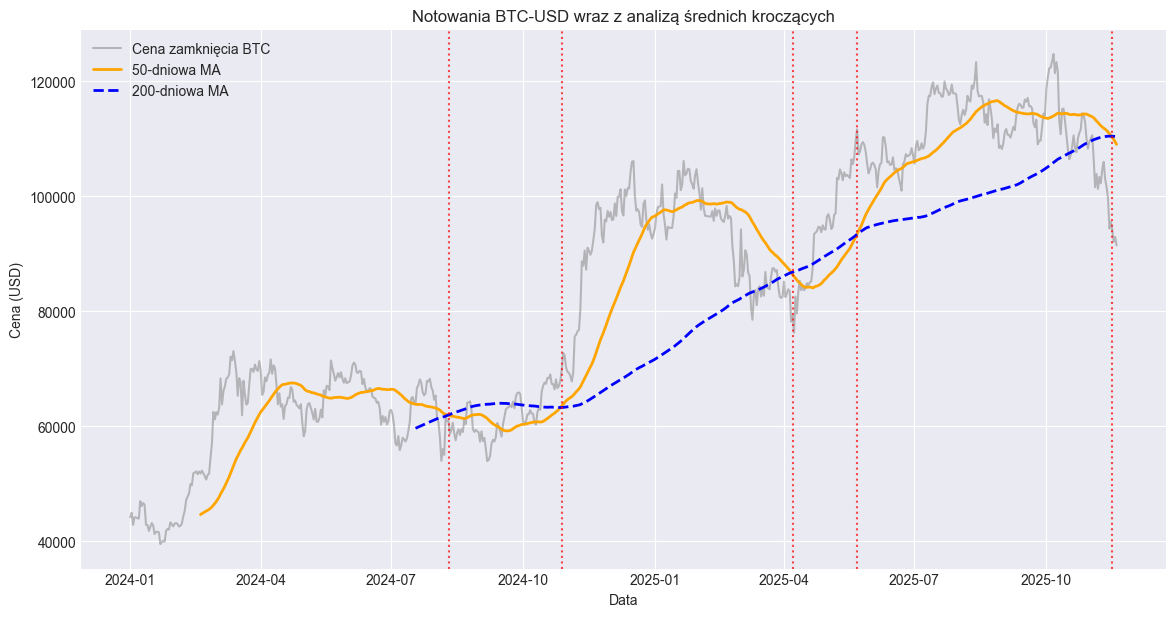

In [2]:
btc_data = yf.download('BTC-USD', start='2024-01-01', end='2025-11-20', auto_adjust=False)

btc_data['50-day MA'] = btc_data['Close'].rolling(window=50).mean()
btc_data['200-day MA'] = btc_data['Close'].rolling(window=200).mean()

diff = btc_data['50-day MA'] - btc_data['200-day MA']
crossover_mask = (diff.shift(1) * diff < 0) & (~diff.isna())
crossover_dates = btc_data.index[crossover_mask]

print(f"Znalezione daty przecięć: {crossover_dates.strftime('%Y-%m-%d').tolist()}")

plt.figure(figsize=(14, 7))
plt.plot(btc_data.index, btc_data['Close'], label='Cena zamknięcia BTC', alpha=0.5, color='gray')
plt.plot(btc_data.index, btc_data['50-day MA'], label='50-dniowa MA', color='orange', linewidth=2)
plt.plot(btc_data.index, btc_data['200-day MA'], label='200-dniowa MA', color='blue', linestyle='--', linewidth=2)

for date in crossover_dates:
    plt.axvline(date, color='red', linestyle=':', alpha=0.7)

plt.title('Notowania BTC-USD wraz z analizą średnich kroczących')
plt.xlabel('Data')
plt.ylabel('Cena (USD)')
plt.legend()
plt.show()

## 2. Analiza dziennego wolumenu obrotu
Zbadamy teraz, w którym dniu w analizowanym okresie wyhandlowano najwięcej fizycznych sztuk Bitcoina (wolumen w USD podzielony przez cenę zamknięcia).

Największa dzienna liczba wyhandlowanych BTC: 2018672 (w dniu 2024-08-05)


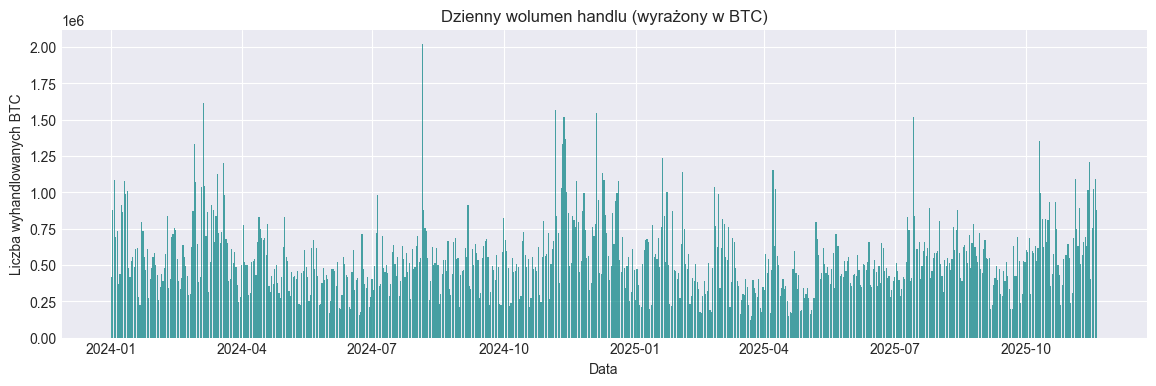

In [3]:
btc_data['BTC_traded'] = btc_data['Volume'] / btc_data['Close']
max_btc = int(btc_data['BTC_traded'].max())
max_date = btc_data['BTC_traded'].idxmax().strftime('%Y-%m-%d')

print(f"Największa dzienna liczba wyhandlowanych BTC: {max_btc} (w dniu {max_date})")

plt.figure(figsize=(14, 4))
plt.bar(btc_data.index, btc_data['BTC_traded'], color='teal', alpha=0.7)
plt.title('Dzienny wolumen handlu (wyrażony w BTC)')
plt.xlabel('Data')
plt.ylabel('Liczba wyhandlowanych BTC')
plt.show()